In [ ]:
from sqlalchemy import create_engine
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib
import scipy.stats as stats
%config InlineBackend.figure_format = 'retina'

In [ ]:
feature_set = pd.read_csv("data/user_activation_feature_set.csv")

In [35]:
feature_set.shape

(130979, 12)

In [36]:
print(feature_set['is_activated'].value_counts())
print(feature_set['is_activated'].value_counts(normalize=True))

is_activated
0    100486
1     30493
Name: count, dtype: int64
is_activated
0    0.767192
1    0.232808
Name: proportion, dtype: float64


## **레슨진입까지의 소요시간**
- 첫 레슨 페이지 진입까지의 시간이 짧으면 활성화율이 높을까?

In [37]:
feature_set['delay_hours'] = feature_set['signup_to_enter_lesson_page_delay'] / 60

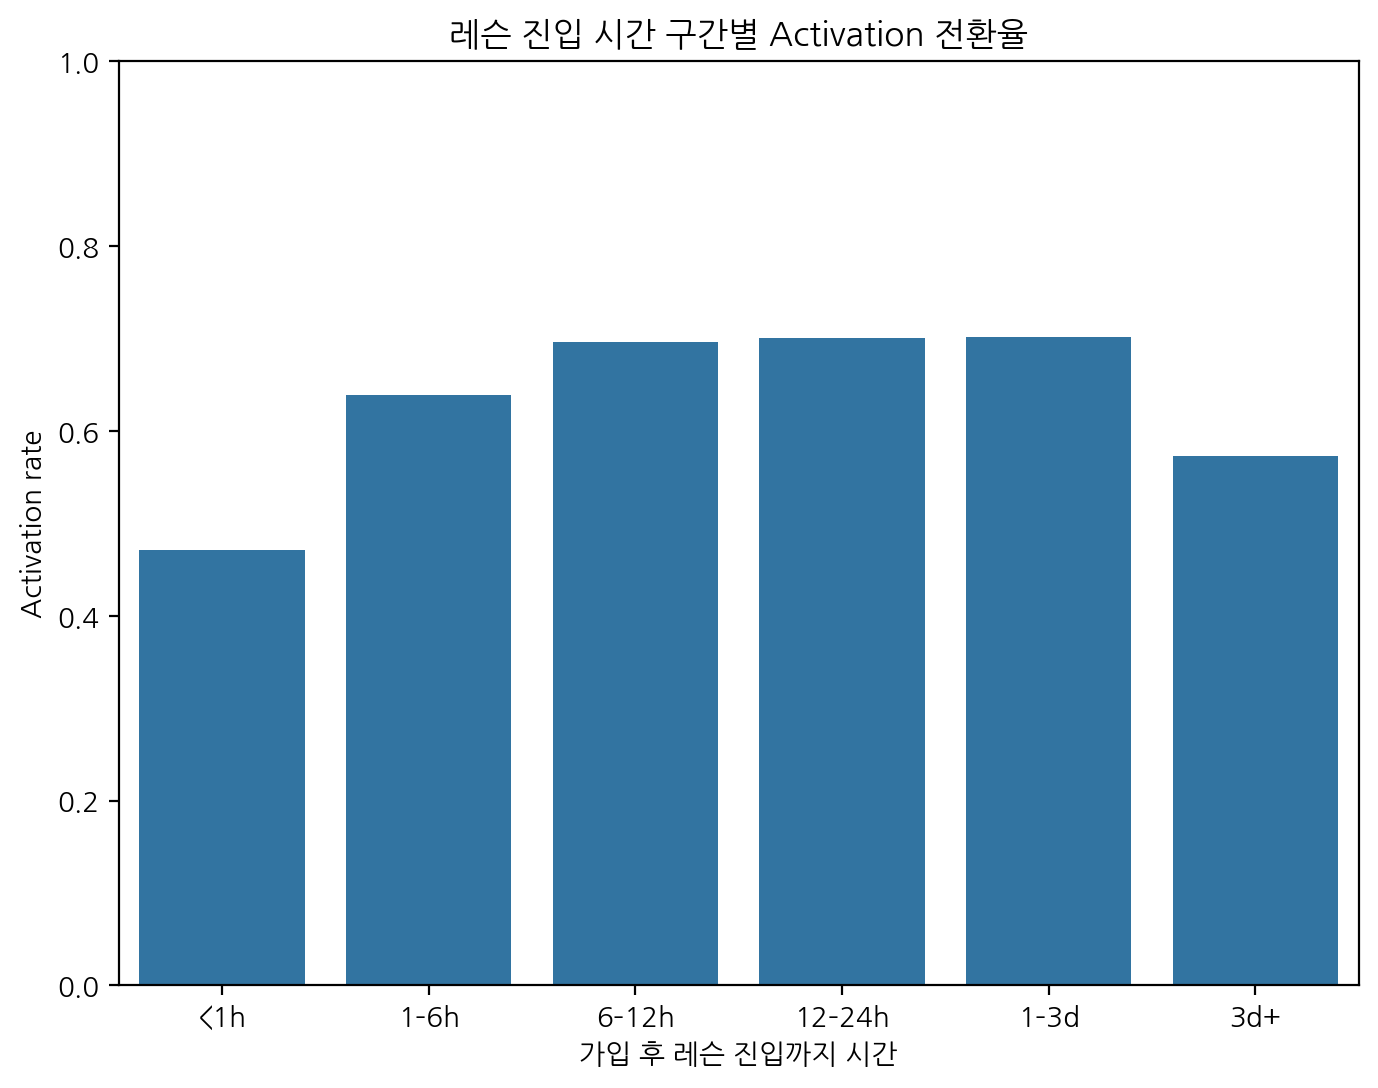

In [38]:
feature_set['delay_category'] = pd.cut(feature_set['delay_hours'], bins=[0, 1, 6, 12, 24, 72, 9999],
                              labels=['<1h', '1–6h', '6–12h', '12–24h', '1–3d', '3d+'])
# 구간별 activation rate 계산
conversion_df = (
    feature_set
    .groupby('delay_category', observed=False)['is_activated']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=conversion_df,
    x='delay_category',
    y='is_activated'
)

plt.title('레슨 진입 시간 구간별 Activation 전환율')
plt.xlabel('가입 후 레슨 진입까지 시간')
plt.ylabel('Activation rate')
plt.ylim(0, 1)
plt.show()


## **가입 이후 첫 레슨 시작 전 콘텐츠 페이지 진입 유무** 
: 콘텐츠 페이지 진입 없이 바로 레슨 시작을 한 유저가 활성화율이 높을까?

1. 콘텐츠 페이지 먼저 봄 -> 1
2. 아무 활동도 안함(레슨페이지 진입 , 콘텐츠 페이지 진입 둘 다 안함) -> -1
3. 콘텐츠 안 보고 바로 레슨진입 -> 0

In [39]:
# 교차표
ct = pd.crosstab(feature_set['is_enter_content_page_before_first_lesson'], feature_set['is_activated'], margins=True)
ct

is_activated,0,1,All
is_enter_content_page_before_first_lesson,,,
-1,32076,86,32162
0,52051,20792,72843
1,16359,9615,25974
All,100486,30493,130979


비즈니스 해석이 어려운 예외 케이스(활동 없음(-1)인데 Activation된 유저 86명)는 분석 대상에서 제외했다.


In [40]:
# 오류 유저만 필터링해서 제거
feature_set = feature_set[
    ~(
        (feature_set['is_enter_content_page_before_first_lesson'] == -1) & 
        (feature_set['is_activated'] == 1)
    )
].reset_index(drop=True)

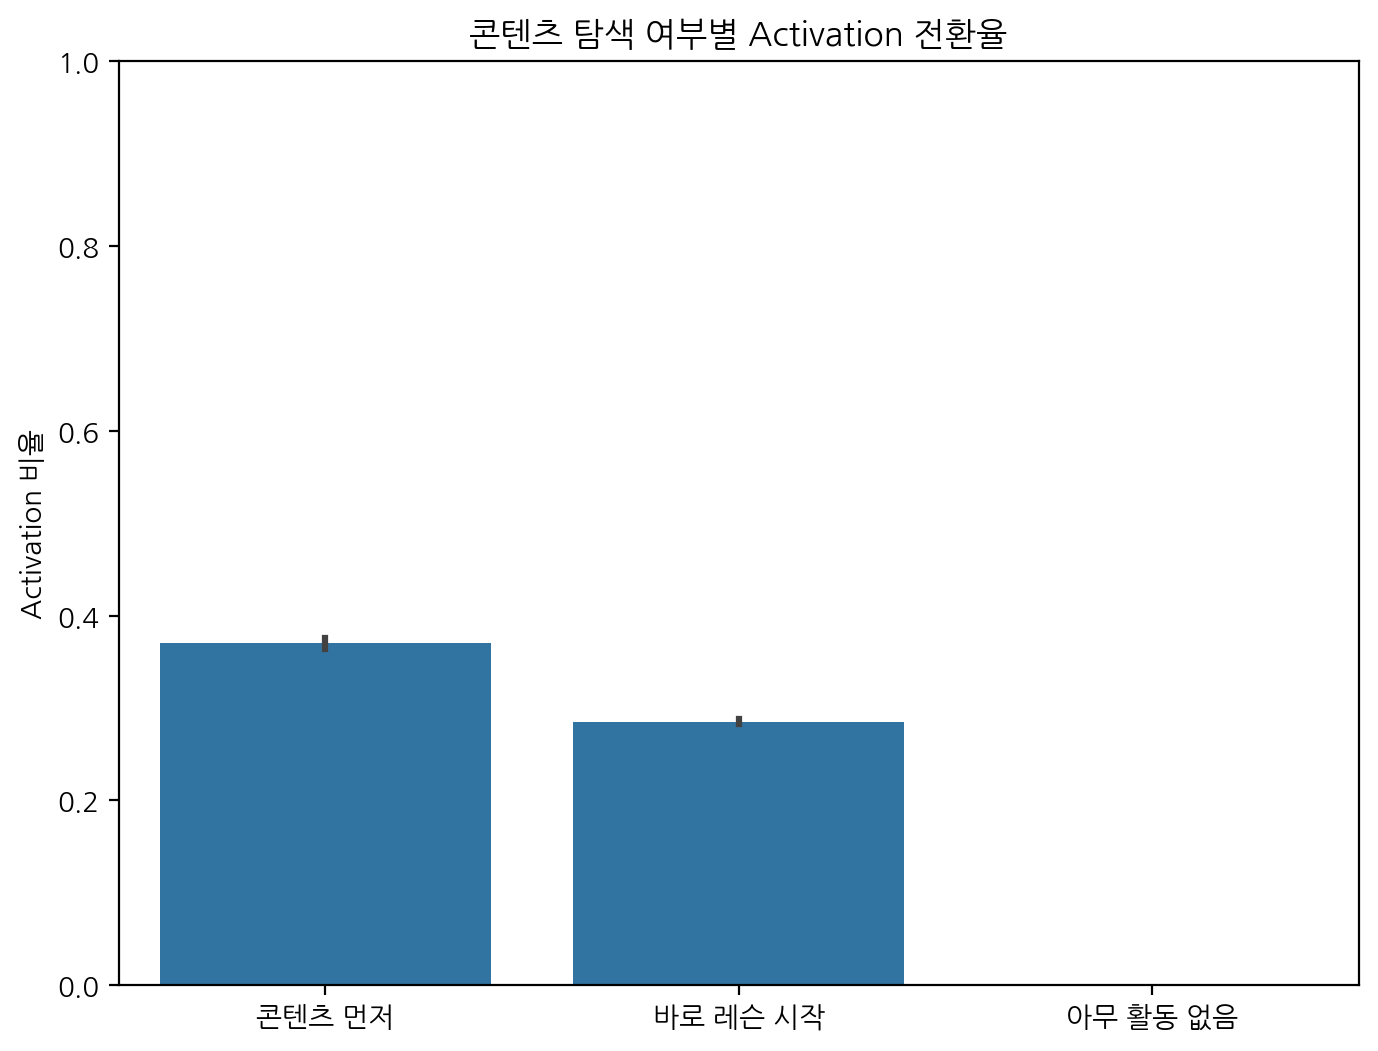

In [41]:
feature_set['content_before_label'] = feature_set['is_enter_content_page_before_first_lesson'].map({
    1: '콘텐츠 먼저',
    0: '바로 레슨 시작',
    -1: '아무 활동 없음'
})

plt.figure(figsize=(8,6))
sns.barplot(data=feature_set, x='content_before_label', y='is_activated')
plt.title('콘텐츠 탐색 여부별 Activation 전환율')
plt.ylabel('Activation 비율')
plt.ylim(0, 1)
plt.xlabel('')
plt.show()

In [ ]:
contingency = pd.crosstab(feature_set['is_enter_content_page_before_first_lesson'], feature_set['is_activated'])
chi2, p, _, _ = stats.chi2_contingency(contingency)

print(f"Chi-square: {chi2:.4f}, p-value: {p:.4f}")

Chi-square: 13627.7892, p-value: 0.0000
